# Install libraries

In [6]:
# !uv pip install yfinance
# !uv pip install snowflake-snowpark-python

In [7]:
import snowflake.connector
import snowflake.snowpark
import sqlalchemy
import yfinance as yf
import pandas as pd
from configparser import ConfigParser

## Using YFinance

In [8]:
def get_stock_data(ticker, start, end=None):
    """Fetch stock data and return a clean DataFrame."""
    stock = yf.Ticker(ticker)
    hist = stock.history(start=start, end=end)
    hist.index = hist.index.tz_localize(None).normalize()
    return hist[['Open', 'High', 'Low', 'Close', 'Volume']]

In [10]:
hig = get_stock_data("HIG", '2020-01-01', '2026-05-31')
hig.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,52.884990,52.928366,52.251689,52.876316,1612000
2020-01-03,52.312421,52.720164,52.303747,52.607384,1326800
2020-01-06,52.503277,52.772214,52.329769,52.468575,2050400
2020-01-07,52.130235,52.477250,51.913351,52.000103,1413900
2020-01-08,52.104205,52.772208,52.000099,52.277710,1656100


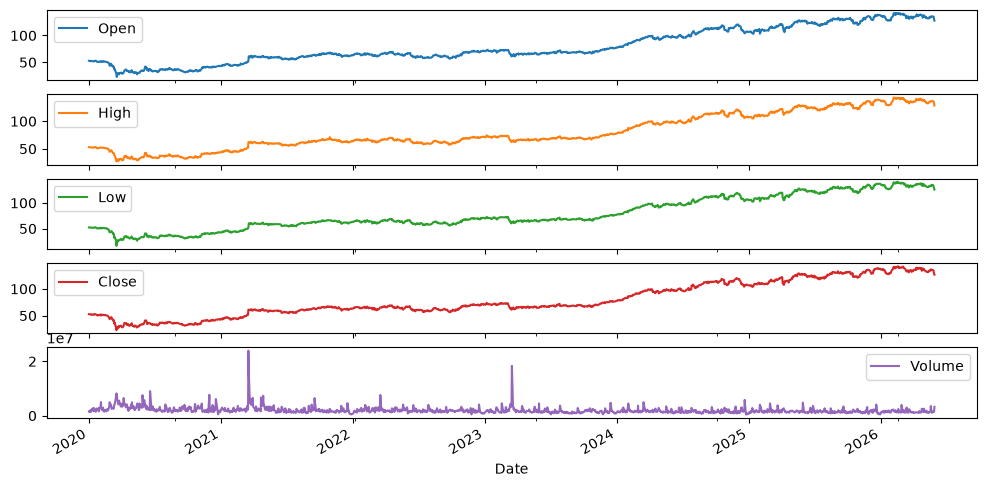

In [ ]:
hig.plot(subplots=True, figsize=(12,6));

In [14]:
config = ConfigParser()
config.read('snow.cfg')
config.sections()

['DEV', 'PROD']

In [15]:
params = dict(config["DEV"])
print(params.keys())

dict_keys(['account', 'user', 'password', 'role', 'warehouse', 'database', 'schema'])


# Snowflake Python Connector

In [ ]:
from snowflake import connector 
from snowflake.connector.pandas_tools import write_pandas

conn = connector.connect(**params)

In [19]:
cursor =  conn.cursor()
cursor.execute("SELECT CURRENT_USER(), CURRENT_WAREHOUSE(), CURRENT_SCHEMA()")
cursor.fetchall()

[('ATWAN', 'COMPUTE_WH', 'ATWAN')]

In [63]:
hig_df = hig.reset_index()
hig_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1610 non-null   datetime64[ns]
 1   Open    1610 non-null   float64       
 2   High    1610 non-null   float64       
 3   Low     1610 non-null   float64       
 4   Close   1610 non-null   float64       
 5   Volume  1610 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 75.6 KB


In [64]:
success, nchunks, nrows, copy_output = write_pandas(
    conn=conn,
    df=hig_df,
    table_name='HIG_STOCK',
    auto_create_table=True,
    overwrite=True
)

In [65]:
print(f"Success:        {success}")
print(f"Chunks written: {nchunks}")
print(f"Rows written:   {nrows}")
print(f"COPY INTO log:  {copy_output}")

Success:        True
Chunks written: 1
Rows written:   1610
COPY INTO log:  [('snowpark_temp_stage_xpwql8sz5s/file0.txt', 'LOADED', 1610, 1610, 1, 0, None, None, None, None)]


## Validation 

In [66]:
cursor.execute("SELECT COUNT(*) FROM HIG_STOCK")
print(f"Row count: {cursor.fetchone()}")

Row count: (1610,)


In [67]:
query = "SELECT * FROM HIG_STOCK LIMIT 10"
for row in cursor.execute(query).fetchall():
    print(row)

(1577923200000000000, 52.88498997380434, 52.92836610881675, 52.251689136339536, 52.87631607055664, 1612000)
(1578009600000000000, 52.31242134882533, 52.72016433726592, 52.30374744475496, 52.607383728027344, 1326800)
(1578268800000000000, 52.503276756618526, 52.7722140959067, 52.32976890254187, 52.46857452392578, 2050400)
(1578355200000000000, 52.13023471144234, 52.477250410827466, 51.91335072667338, 52.00010299682617, 1413900)
(1578441600000000000, 52.104205434809074, 52.772208450440985, 52.000098747867966, 52.2777099609375, 1656100)
(1578528000000000000, 52.494601181976385, 52.598707883303526, 52.14758877238074, 52.590030670166016, 1774900)
(1578614400000000000, 52.572686451627206, 52.5900375707918, 51.82660818387535, 51.843955993652344, 2479800)
(1578873600000000000, 51.896008039876996, 52.034813680298896, 51.297409336067716, 51.6183967590332, 2715500)
(1578960000000000000, 51.522968562576395, 52.25169902055126, 51.488266324247206, 51.843955993652344, 2348600)
(1579046400000000000, 5

In [68]:
cursor.fetchall()

[]

In [69]:
results = cursor.execute(query)
results.fetchone()

(1577923200000000000,
 52.88498997380434,
 52.92836610881675,
 52.251689136339536,
 52.87631607055664,
 1612000)

In [71]:
col_names = [desc[0] for desc in cursor.description]
rows = cursor.execute(query).fetchall()
df = pd.DataFrame(rows, columns=col_names)
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-02,52.884990,52.928366,52.251689,52.876316,1612000
1,2020-01-03,52.312421,52.720164,52.303747,52.607384,1326800
2,2020-01-06,52.503277,52.772214,52.329769,52.468575,2050400
3,2020-01-07,52.130235,52.477250,51.913351,52.000103,1413900
4,2020-01-08,52.104205,52.772208,52.000099,52.277710,1656100


In [72]:
# Append 
hig_2019 = get_stock_data("HIG", '2019-06-01', '2019-12-31')
hig_2019_reset = hig_2019.reset_index()

In [73]:
success, nchunks, nrows, copy_output = write_pandas(
    conn=conn, # this is same connection 
    df=hig_2019_reset, # the new dataset with index reset 
    table_name='HIG_STOCK', # name of the existing table
    auto_create_table=False, 
    overwrite=False
)

cursor.execute("SELECT COUNT(*) FROM HIG_STOCK")
print(f"Row count: {cursor.fetchone()}")

Row count: (1757,)


In [74]:
hig_2019_reset.shape

(147, 6)

In [75]:
hig_df.shape

(1610, 6)

# SQLAlchemy

In [ ]:
from snowflake.sqlalchemy import URL
from sqlalchemy import create_engine, text

In [81]:
url = URL(**params)
engine = create_engine(url)

In [ ]:
# from snowflake.connector.pandas_tools import pd_writer

In [86]:
hig_df.to_sql(
    name='high_sqlalchemy',
    con=engine,
    index=False, 
    if_exists='replace'
)

1610

In [ ]:
hig_df.to_sql(
    name='high_sqlalchemy',
    con=engine,
    index=False, 
    if_exists='replace'
)

1610

In [93]:
df = pd.read_sql("SELECT * FROM HIGH_SQLALCHEMY", con=engine)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1610 non-null   datetime64[ns]
 1   Open    1610 non-null   float64       
 2   High    1610 non-null   float64       
 3   Low     1610 non-null   float64       
 4   Close   1610 non-null   float64       
 5   Volume  1610 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 75.6 KB


In [95]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-02,52.884990,52.928366,52.251689,52.876316,1612000
1,2020-01-03,52.312421,52.720164,52.303747,52.607384,1326800
2,2020-01-06,52.503277,52.772214,52.329769,52.468575,2050400
3,2020-01-07,52.130235,52.477250,51.913351,52.000103,1413900
4,2020-01-08,52.104205,52.772208,52.000099,52.277710,1656100


In [97]:
hig_2019_reset.to_sql(
    name='high_sqlalchemy',
    con=engine,
    index=False, 
    if_exists='append'
)

147

In [98]:
df = pd.read_sql("SELECT * FROM HIGH_SQLALCHEMY", con=engine)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1757 non-null   datetime64[ns]
 1   Open    1757 non-null   float64       
 2   High    1757 non-null   float64       
 3   Low     1757 non-null   float64       
 4   Close   1757 non-null   float64       
 5   Volume  1757 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 82.5 KB


# SnowPark

In [99]:
from snowflake.snowpark import Session

In [100]:
session = Session.builder.configs(params).create()
session

In [102]:
session.sql('SELECT * FROM HIG_STOCK LIMIT 5').collect()

[Row(Date=1577923200000000000, Open=52.88498997380434, High=52.92836610881675, Low=52.251689136339536, Close=52.87631607055664, Volume=1612000),
 Row(Date=1578009600000000000, Open=52.31242134882533, High=52.72016433726592, Low=52.30374744475496, Close=52.607383728027344, Volume=1326800),
 Row(Date=1578268800000000000, Open=52.503276756618526, High=52.7722140959067, Low=52.32976890254187, Close=52.46857452392578, Volume=2050400),
 Row(Date=1578355200000000000, Open=52.13023471144234, High=52.477250410827466, Low=51.91335072667338, Close=52.00010299682617, Volume=1413900),
 Row(Date=1578441600000000000, Open=52.104205434809074, High=52.772208450440985, Low=52.000098747867966, Close=52.2777099609375, Volume=1656100)]

In [104]:
high_sndf = session.create_dataframe(hig_df)
type(high_sndf)

snowflake.snowpark.table.Table

In [ ]:
high_sndf.show(5)

----------------------------------------------------------------------------------------------------------------------
|"Date"               |"Open"              |"High"              |"Low"               |"Close"             |"Volume"  |
----------------------------------------------------------------------------------------------------------------------
|2020-01-02 00:00:00  |52.88498997380434   |52.92836610881675   |52.251689136339536  |52.87631607055664   |1612000   |
|2020-01-03 00:00:00  |52.31242134882533   |52.72016433726592   |52.30374744475496   |52.607383728027344  |1326800   |
|2020-01-06 00:00:00  |52.503276756618526  |52.7722140959067    |52.32976890254187   |52.46857452392578   |2050400   |
|2020-01-07 00:00:00  |52.13023471144234   |52.477250410827466  |51.91335072667338   |52.00010299682617   |1413900   |
|2020-01-08 00:00:00  |52.104205434809074  |52.772208450440985  |52.000098747867966  |52.2777099609375    |1656100   |
------------------------------------------------

In [115]:
high_sndf.write.mode("overwrite").save_as_table('HIG_SNOWPARK')
session.table("HIG_SNOWPARK").count()

1610

In [110]:
snow_df = session.table("HIG_SNOWPARK")
print(snow_df.schema)

StructType([StructField('"Date"', TimestampType(timezone=TimestampTimeZone('ntz')), nullable=True), StructField('"Open"', DoubleType(), nullable=True), StructField('"High"', DoubleType(), nullable=True), StructField('"Low"', DoubleType(), nullable=True), StructField('"Close"', DoubleType(), nullable=True), StructField('"Volume"', LongType(), nullable=True)])


In [111]:
snow_df.show(5)

----------------------------------------------------------------------------------------------------------------------
|"Date"               |"Open"              |"High"              |"Low"               |"Close"             |"Volume"  |
----------------------------------------------------------------------------------------------------------------------
|2020-01-02 00:00:00  |52.88498997380434   |52.92836610881675   |52.251689136339536  |52.87631607055664   |1612000   |
|2020-01-03 00:00:00  |52.31242134882533   |52.72016433726592   |52.30374744475496   |52.607383728027344  |1326800   |
|2020-01-06 00:00:00  |52.503276756618526  |52.7722140959067    |52.32976890254187   |52.46857452392578   |2050400   |
|2020-01-07 00:00:00  |52.13023471144234   |52.477250410827466  |51.91335072667338   |52.00010299682617   |1413900   |
|2020-01-08 00:00:00  |52.104205434809074  |52.772208450440985  |52.000098747867966  |52.2777099609375    |1656100   |
------------------------------------------------

In [ ]:
pd_df = snow_df.to_pandas()
pd_df

,Date,Open,High,Low,Close,Volume
0,2020-01-02,52.884990,52.928366,52.251689,52.876316,1612000
1,2020-01-03,52.312421,52.720164,52.303747,52.607384,1326800
2,2020-01-06,52.503277,52.772214,52.329769,52.468575,2050400
3,2020-01-07,52.130235,52.477250,51.913351,52.000103,1413900
4,2020-01-08,52.104205,52.772208,52.000099,52.277710,1656100
...,...,...,...,...,...,...
1605,2026-05-22,135.457676,136.522618,135.308375,135.378052,1067100
1606,2026-05-26,135.298425,136.243939,134.074235,134.721161,1533600
1607,2026-05-27,134.492249,135.497476,130.869428,131.068481,1385600
1608,2026-05-28,129.844286,130.988852,128.032869,128.361313,1603300


In [116]:
session.table("HIG_SNOWPARK").to_pandas()

,Date,Open,High,Low,Close,Volume
0,2020-01-02,52.884990,52.928366,52.251689,52.876316,1612000
1,2020-01-03,52.312421,52.720164,52.303747,52.607384,1326800
2,2020-01-06,52.503277,52.772214,52.329769,52.468575,2050400
3,2020-01-07,52.130235,52.477250,51.913351,52.000103,1413900
4,2020-01-08,52.104205,52.772208,52.000099,52.277710,1656100
...,...,...,...,...,...,...
1605,2026-05-22,135.457676,136.522618,135.308375,135.378052,1067100
1606,2026-05-26,135.298425,136.243939,134.074235,134.721161,1533600
1607,2026-05-27,134.492249,135.497476,130.869428,131.068481,1385600
1608,2026-05-28,129.844286,130.988852,128.032869,128.361313,1603300


In [117]:
hig2019_sndf = session.create_dataframe(hig_2019_reset)
hig2019_sndf.write.mode("append").save_as_table('HIG_SNOWPARK')
session.table("HIG_SNOWPARK").count()

1757